In [1]:
# Prior: Beta(5, 5)
# Posterior: Update with 25 out of 100 cases
prior <- dbeta(seq(0, 1, 0.01), 5, 5)
posterior <- dbeta(seq(0, 1, 0.01), 5 + 25, 5 + 75)

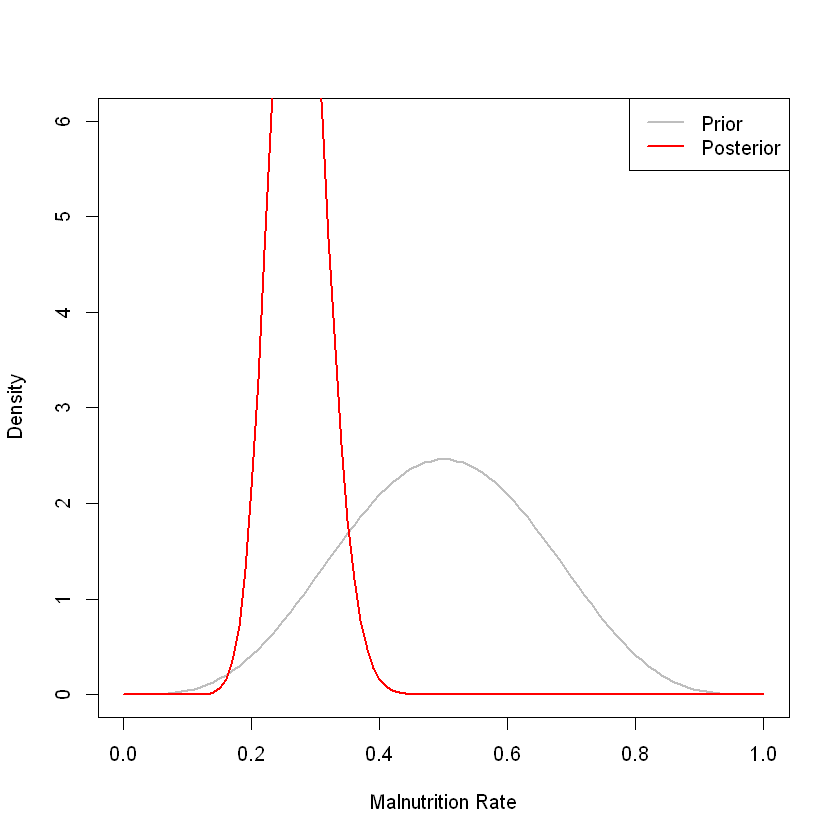

In [4]:
par(bg = "white")
x <- seq(0, 1, 0.01)
plot(x, prior, type = "l", col = "gray", lwd = 2, ylim = c(0, 6),
     ylab = "Density", xlab = "Malnutrition Rate")
lines(x, posterior, col = "red", lwd = 2)
legend("topright", legend = c("Prior", "Posterior"), col = c("gray", "red"), lwd = 2)

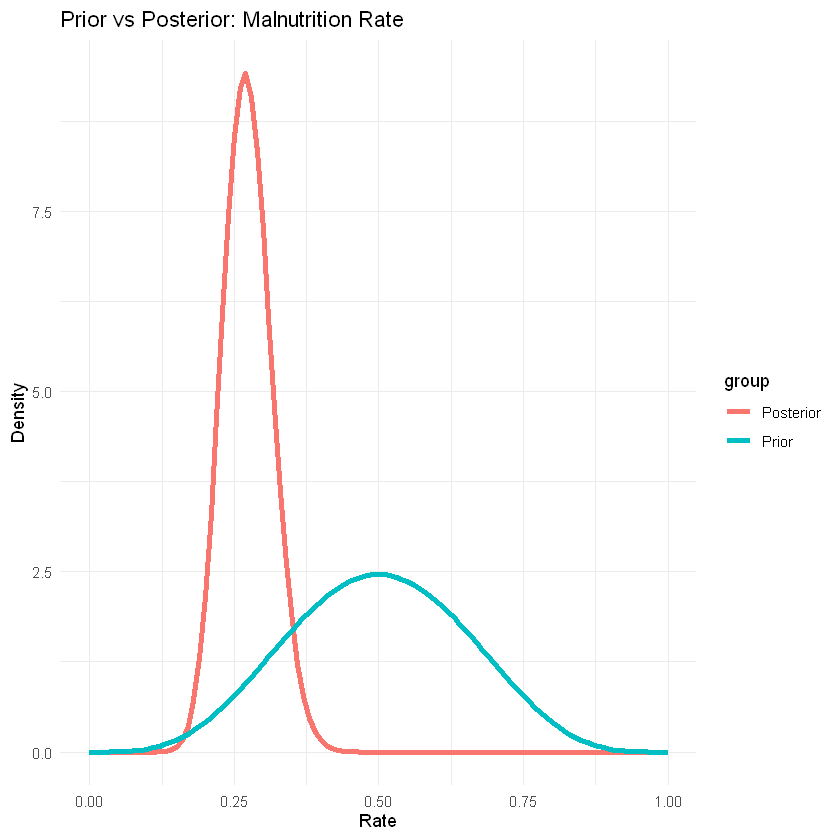

In [6]:
library(ggplot2)

df <- data.frame(
  x = rep(seq(0, 1, 0.01), 2),
  density = c(dbeta(seq(0, 1, 0.01), 5, 5), dbeta(seq(0, 1, 0.01), 30, 80)),
  group = rep(c("Prior", "Posterior"), each = 101)
)

ggplot(df, aes(x = x, y = density, color = group)) +
  geom_line(linewidth = 1.5) +
  labs(title = "Prior vs Posterior: Malnutrition Rate", x = "Rate", y = "Density") +
  theme_minimal()

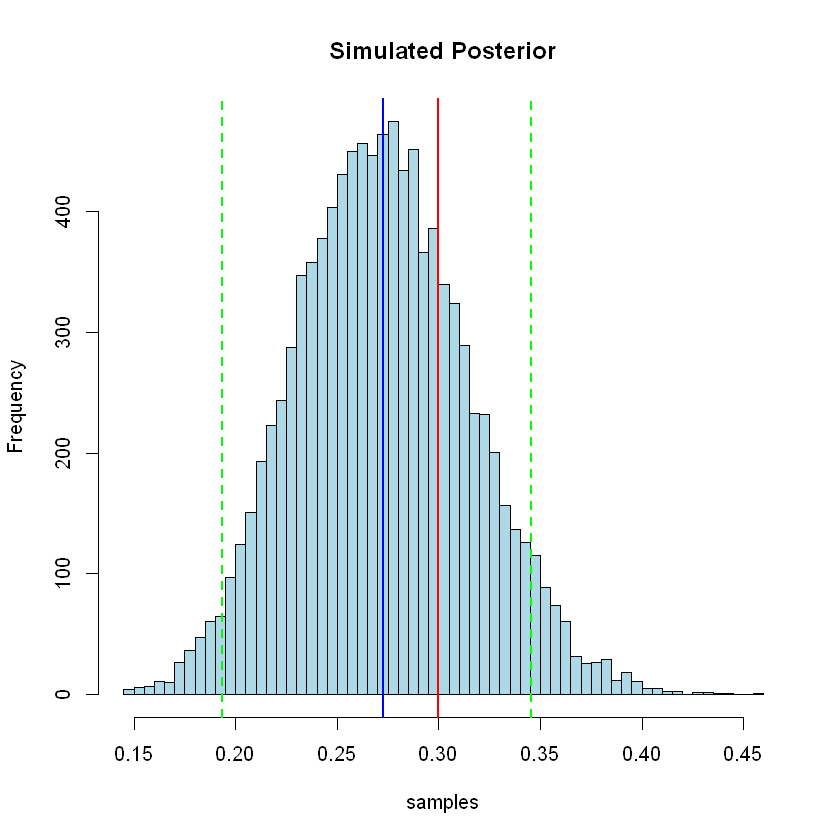

In [10]:
par(bg = "white")
samples <- rbeta(10000, 30, 80)
hist(samples, breaks = 50, col = "lightblue", main = "Simulated Posterior")
abline(v = 0.3, col = "red", lwd = 2)  # Threshold
abline(v = mean(samples), col = "blue", lwd = 2)  # Mean
abline(v = quantile(samples, c(0.025, 0.95)), col = "green", lwd = 2, lty = 2)  # 95% interval